# Titanic Survival Prediction — Logistic Regression

**Binary Classification Machine Learning Project**

Objective: predict whether a Titanic passenger survived (`1`) or did not survive (`0`) using Logistic Regression.


# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Load Dataset

In [2]:
df = pd.read_csv("/content/tested.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# Explore Data

In [4]:
df.shape

(418, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,418.0,1100.500000,120.810458,892.00,996.2500,1100.5000,1204.75,1309.0000
Survived,418.0,0.363636,0.481622,0.00,0.0000,0.0000,1.00,1.0000
Pclass,418.0,2.265550,0.841838,1.00,1.0000,3.0000,3.00,3.0000
Age,332.0,30.272590,14.181209,0.17,21.0000,27.0000,39.00,76.0000
SibSp,418.0,0.447368,0.896760,0.00,0.0000,0.0000,1.00,8.0000
Parch,418.0,0.392344,0.981429,0.00,0.0000,0.0000,0.00,9.0000
Fare,417.0,35.627188,55.907576,0.00,7.8958,14.4542,31.50,512.3292


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
display(df['Survived'].value_counts())
display((df['Survived'].value_counts(normalize=True) * 100).round(2).to_frame('Percentage'))

,count
Survived,
0,266
1,152


,Percentage
Survived,
0,63.64
1,36.36


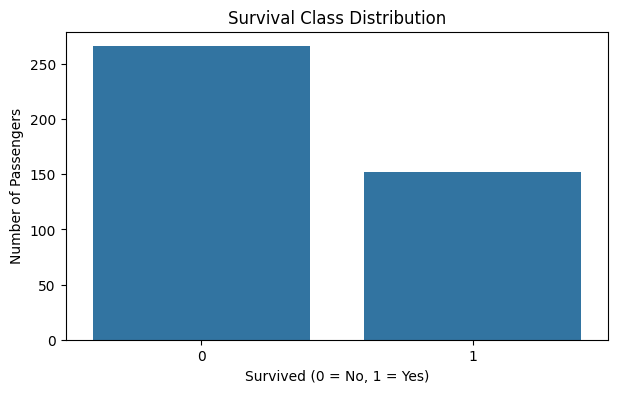

In [29]:
plt.figure(figsize=(7,4))
sb.countplot(data=df, x='Survived')
plt.title('Survival Class Distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

# Preprocessing

In [10]:
df.drop(['Cabin'],axis=1,inplace=True)

In [11]:
df['Age'].fillna(df['Age'].median(),inplace=True)

/tmp/ipykernel_1021/1527141296.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)


In [12]:
df['Fare'].fillna(df['Fare'].median(),inplace=True)


/tmp/ipykernel_1021/2541859169.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fare'].fillna(df['Fare'].median(),inplace=True)


In [13]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [15]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,34.5,0,0,7.8292,Q
1,1,3,female,47.0,1,0,7.0000,S
2,0,2,male,62.0,0,0,9.6875,Q
3,0,3,male,27.0,0,0,8.6625,S
4,1,3,female,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...,...
413,0,3,male,27.0,0,0,8.0500,S
414,1,1,female,39.0,0,0,108.9000,C
415,0,3,male,38.5,0,0,7.2500,S
416,0,3,male,27.0,0,0,8.0500,S


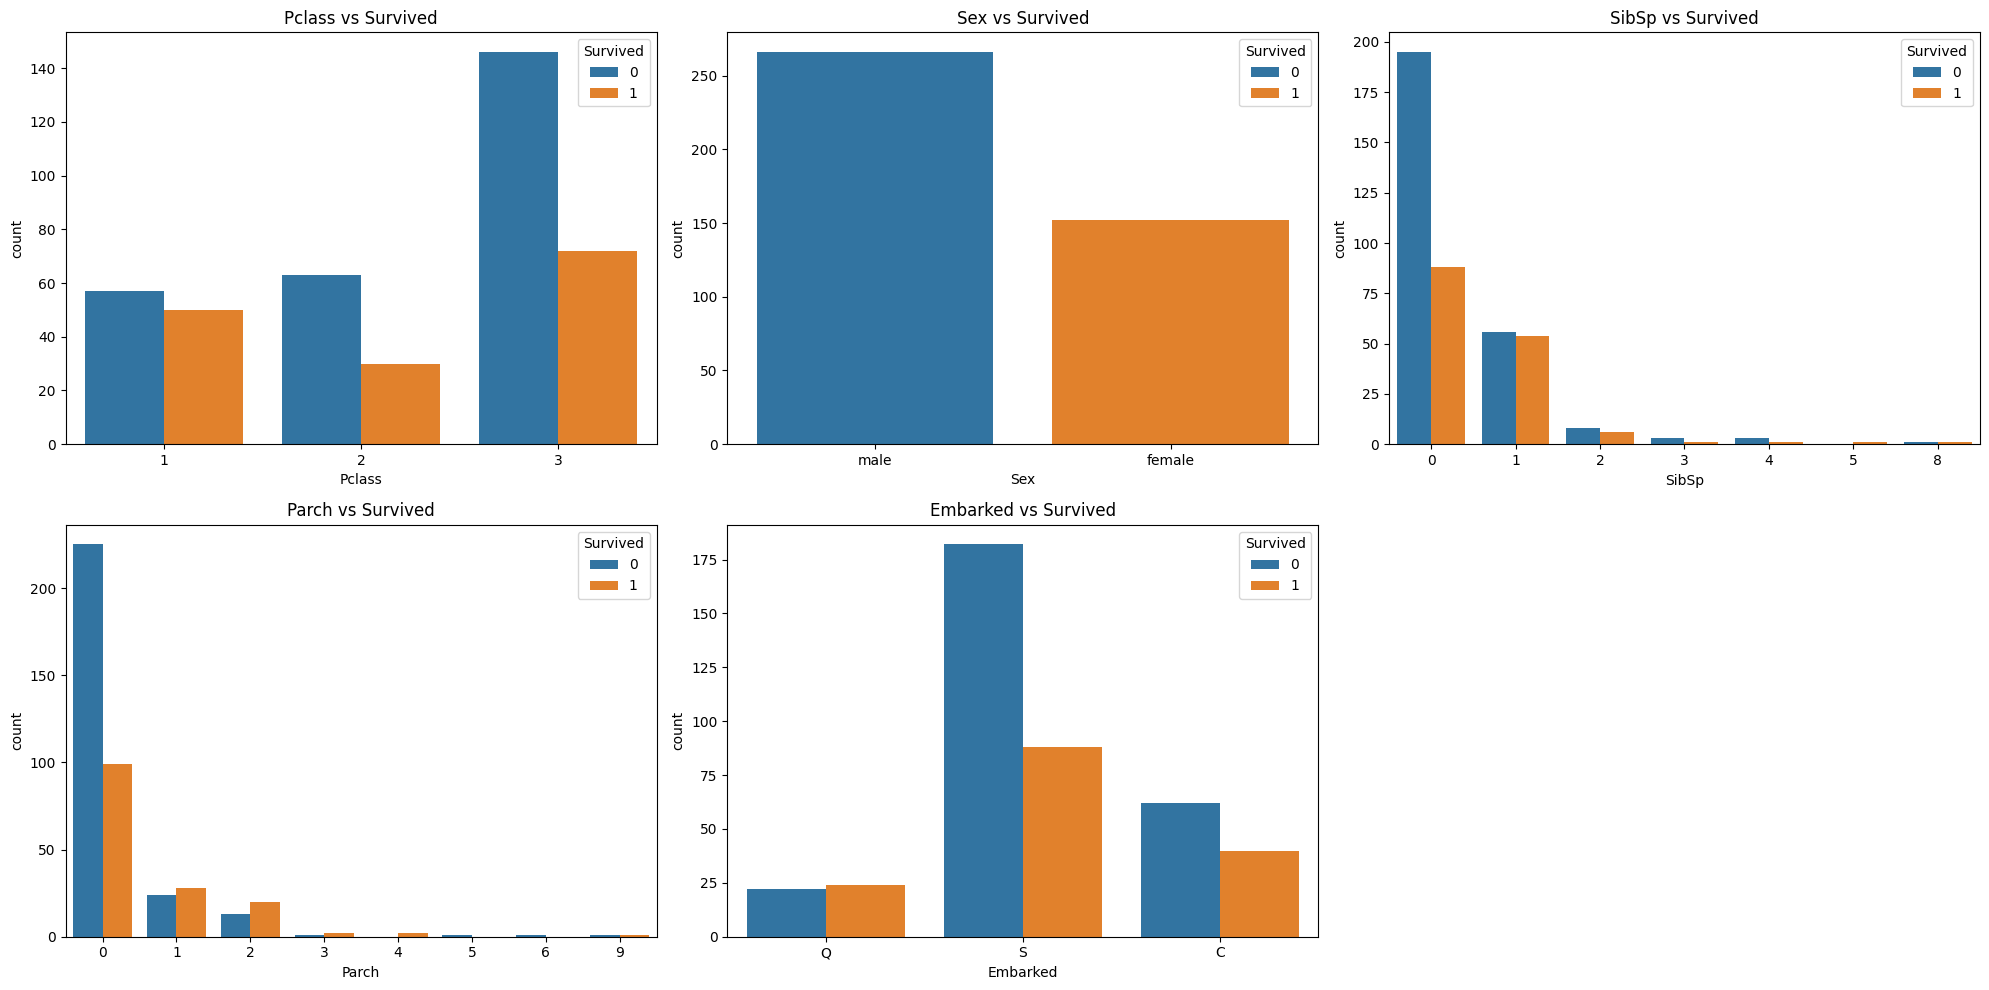

In [16]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sb.countplot(data =df,x= 'Pclass' , hue= 'Survived')
plt.title('Pclass vs Survived')
plt.subplot(2,3,2)
sb.countplot(data =df,x= 'Sex' , hue= 'Survived')
plt.title('Sex vs Survived')
plt.subplot(2,3,3)
sb.countplot(data =df,x= 'SibSp' , hue= 'Survived')
plt.title('SibSp vs Survived')
plt.subplot(2,3,4)
sb.countplot(data =df,x= 'Parch' , hue= 'Survived')
plt.title('Parch vs Survived')
plt.subplot(2,3,5)
sb.countplot(data =df,x= 'Embarked' , hue= 'Survived')
plt.title('Embarked vs Survived')
plt.tight_layout()

Text(0.5, 1.0, 'Age vs Survived')

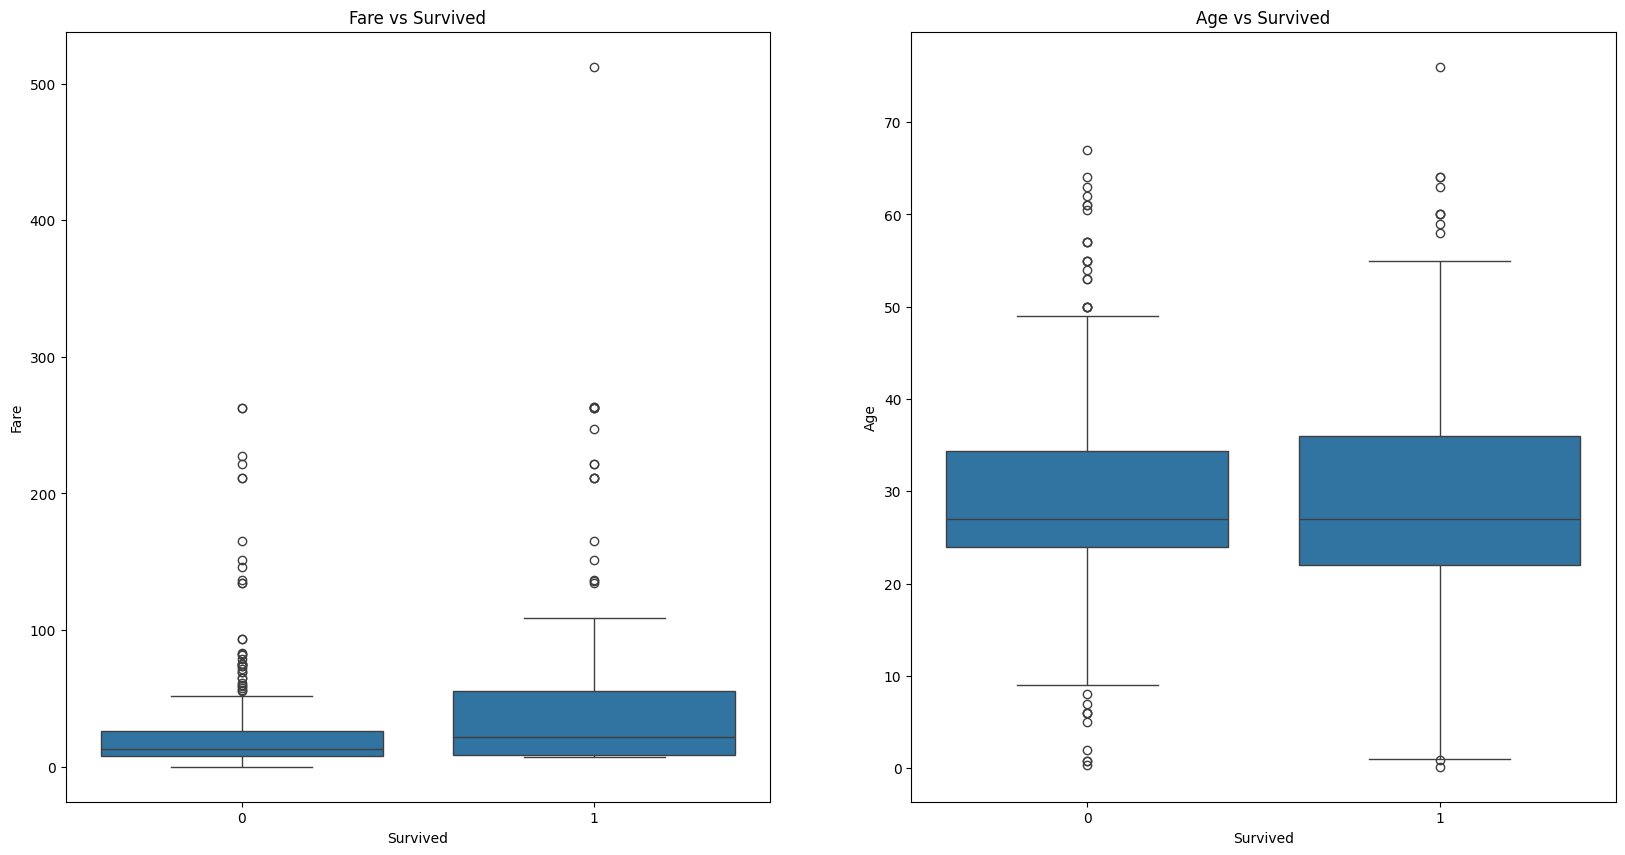

In [17]:
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
sb.boxplot(data =df,x= 'Survived' , y= 'Fare' )
plt.title('Fare vs Survived')
plt.subplot(1,2,2)
sb.boxplot(data =df,x= 'Survived' , y= 'Age' )
plt.title('Age vs Survived')

# Insights
* Female passengers had a higher survival rate than male passengers.
* First-class passengers had a higher survival rate compared with second- and third-class passengers.
* Passenger class and gender were important factors related to survival.
* Age had an impact on survival, with different survival patterns across age groups.

# Train-Test Split — 80/20

In [18]:
X=df.drop(['Survived'],axis=1)
y=df['Survived']

In [19]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#    Categorical Feature Encoding

In [20]:
sex_encoder = LabelEncoder()
embarked_encoder = LabelEncoder()

x_train['Sex'] = sex_encoder.fit_transform(x_train['Sex'])
x_test['Sex'] = sex_encoder.transform(x_test['Sex'])

x_train['Embarked'] = embarked_encoder.fit_transform(x_train['Embarked'])
x_test['Embarked'] = embarked_encoder.transform(x_test['Embarked'])

#    Feature Scaling

In [21]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#    Logistic Regression Model Training

In [22]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

#    Model Prediction

In [24]:
y_pred = model.predict(x_test)

#    Model Evaluation – Accuracy

In [25]:
print("Accuracy",accuracy_score(y_test, y_pred))

Accuracy 1.0


In [26]:
print(confusion_matrix(y_test, y_pred))

[[50  0]
 [ 0 34]]


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



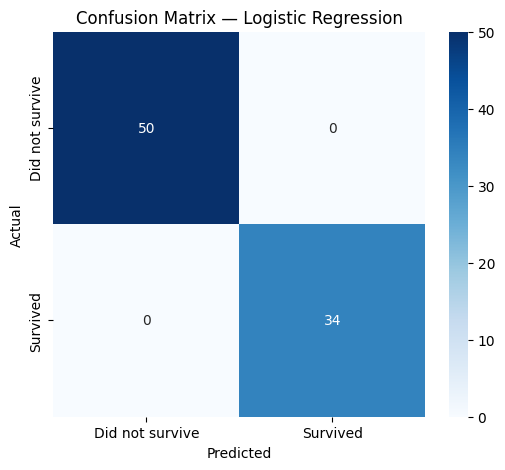

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sb.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Did not survive','Survived'],
    yticklabels=['Did not survive','Survived']
)
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 9. Final Insights

- Logistic Regression was used as the required binary classification algorithm.
- Missing values were handled through preprocessing pipelines.
- Categorical features were encoded using One-Hot Encoding.
- Numerical features were standardized.
- The data was split into 80% training and 20% testing with `random_state=42`.
- The model was evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.